<a href="https://colab.research.google.com/github/jaqcquesndav/Wanzo_Scoring/blob/main/xgboost_Wanzo_Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_DIR="/content/drive/MyDrive/kiotadata/dataset"

In [ ]:
#Importation des packages
import matplotlib.pyplot as plt
import  seaborn as sns
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error

In [ ]:
##Importation et nettoyyage des données

In [ ]:
#Chargement des données
data=pd.read_csv("/content/drive/MyDrive/kiotaData/dataset/matching.csv", encoding='latin1')

In [ ]:
#Affichage des informations générales sur la DataFrame
data.info()

In [ ]:
data.columns

In [ ]:
data.head()

,ID_PME,ID_Produit,Score_Matching,Nom,Secteur,Taille,Historique_Credit,Score_Risque,Benefice_Net,Garantie,Institution,Secteur_Cible,Taille_Cible,Tolerance_Risque,Montant_Min,Montant_Max,Garantie_Req,Taux_Interet,Type_Produit,Maturite
0,1,1,12.5,Produit_1,Agriculture,Petite,Bon,85,744891,Non,TMB,Industrie,Moyenne,Moyen,27986,251752,Oui,5.40,Crédit,35
1,1,2,50.0,Produit_2,Agriculture,Petite,Bon,85,744891,Non,TMB,Agriculture,Petite,Faible,32738,81228,Non,7.57,Crédit,22
2,1,3,50.0,Produit_3,Agriculture,Petite,Bon,85,744891,Non,Equity BCDC,Commerce,Grande,Faible,48891,100939,Non,16.47,Leasing,7
3,1,4,12.5,Produit_4,Agriculture,Petite,Bon,85,744891,Non,SMICO SA,Commerce,Moyenne,Faible,41512,371506,Oui,7.06,Crédit,60
4,1,5,62.5,Produit_5,Agriculture,Petite,Bon,85,744891,Non,Bonne Moisson,Industrie,Grande,Elevé,20722,190944,Non,17.69,Leasing,41


In [ ]:
##Description des données

In [ ]:
#Affichage des statistiques descriptives du dataFrame
data.describe()

In [ ]:
#Affichage du nombre des valeurs uniques pour chaque variable
print(data.nunique())

In [ ]:
# Affichage du nombre de valeurs manquantes pour chaque variable
print(data.isnull().sum())

In [ ]:

num=['ID_PME', 'ID_Produit','Nom','Institution']
data1=data.drop(columns=num)
data1.head()

,Score_Matching,Secteur,Taille,Historique_Credit,Score_Risque,Benefice_Net,Garantie,Secteur_Cible,Taille_Cible,Tolerance_Risque,Montant_Min,Montant_Max,Garantie_Req,Taux_Interet,Type_Produit,Maturite
0,12.5,Agriculture,Petite,Bon,85,744891,Non,Industrie,Moyenne,Moyen,27986,251752,Oui,5.40,Crédit,35
1,50.0,Agriculture,Petite,Bon,85,744891,Non,Agriculture,Petite,Faible,32738,81228,Non,7.57,Crédit,22
2,50.0,Agriculture,Petite,Bon,85,744891,Non,Commerce,Grande,Faible,48891,100939,Non,16.47,Leasing,7
3,12.5,Agriculture,Petite,Bon,85,744891,Non,Commerce,Moyenne,Faible,41512,371506,Oui,7.06,Crédit,60
4,62.5,Agriculture,Petite,Bon,85,744891,Non,Industrie,Grande,Elevé,20722,190944,Non,17.69,Leasing,41


In [ ]:
threshold = data1['Score_Matching'].median()
data1['Score_Matching_binary'] = (data1['Score_Matching'] >= threshold).astype(int)

In [ ]:
#5. Modelisation du prix du bien immobilier
#5.1 variablesgorielles

from sklearn.preprocessing import OneHotEncoder
#sélection des variables catégorielles
cat_vars=['Secteur','Taille','Historique_Credit','Garantie','Secteur_Cible','Taille_Cible','Tolerance_Risque','Garantie_Req','Type_Produit']

#encodage binaire des variables catégorielles
encoder=OneHotEncoder(sparse=False)
cat_data=pd.DataFrame(encoder.fit_transform(data1[cat_vars]))
cat_data.columns=encoder.get_feature_names_out(cat_vars)

#Remplacement des variables catégorielles par les variables encodées
data1=pd.concat([data1.drop(cat_vars, axis=1), cat_data], axis=1)
data1


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,Score_Matching,Score_Risque,Benefice_Net,Montant_Min,Montant_Max,Taux_Interet,Maturite,Score_Matching_binary,Secteur_Agriculture,Secteur_Commerce,...,Taille_Cible_Grande,Taille_Cible_Moyenne,Taille_Cible_Petite,Tolerance_Risque_Elevé,Tolerance_Risque_Faible,Tolerance_Risque_Moyen,Garantie_Req_Non,Garantie_Req_Oui,Type_Produit_Crédit,Type_Produit_Leasing
0,12.5,85,744891,27986,251752,5.40,35,0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1,50.0,85,744891,32738,81228,7.57,22,1,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,50.0,85,744891,48891,100939,16.47,7,1,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,12.5,85,744891,41512,371506,7.06,60,0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,62.5,85,744891,20722,190944,17.69,41,1,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,62.5,43,534952,39731,485581,9.47,41,1,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
49996,62.5,43,534952,18589,362850,16.91,33,1,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
49997,37.5,43,534952,29008,345413,15.17,36,0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
49998,50.0,43,534952,17086,286045,18.31,22,1,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


In [ ]:
# Enregistrer l'encodeur
import joblib
encoder_filename = '/content/drive/MyDrive/kiotaData/dataset/encoder_v041.pkl'
joblib.dump(encoder, encoder_filename)

['/content/drive/MyDrive/kiotaData/dataset/encoder_v041.pkl']

In [ ]:
#Analyse bivariées et sélection des variables pertinentes
#41.Corrélation entre les variavles numérique
corr_matrix=data1.select_dtypes(include=np.number).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation entre les variables numérique")
plt.show()

In [ ]:
data1.columns

Index(['Score_Matching', 'Score_Risque', 'Benefice_Net', 'Montant_Min',
       'Montant_Max', 'Taux_Interet', 'Maturite', 'Score_Matching_binary',
       'Secteur_Agriculture', 'Secteur_Commerce', 'Secteur_Industrie',
       'Secteur_Services', 'Taille_Grande', 'Taille_Moyenne', 'Taille_Petite',
       'Historique_Credit_Bon', 'Historique_Credit_Mauvais',
       'Historique_Credit_Moyen', 'Garantie_Non', 'Garantie_Oui',
       'Secteur_Cible_Agriculture', 'Secteur_Cible_Commerce',
       'Secteur_Cible_Industrie', 'Secteur_Cible_Services',
       'Taille_Cible_Grande', 'Taille_Cible_Moyenne', 'Taille_Cible_Petite',
       'Tolerance_Risque_Elevé ', 'Tolerance_Risque_Faible',
       'Tolerance_Risque_Moyen', 'Garantie_Req_Non', 'Garantie_Req_Oui',
       'Type_Produit_Crédit', 'Type_Produit_Leasing'],
      dtype='object')

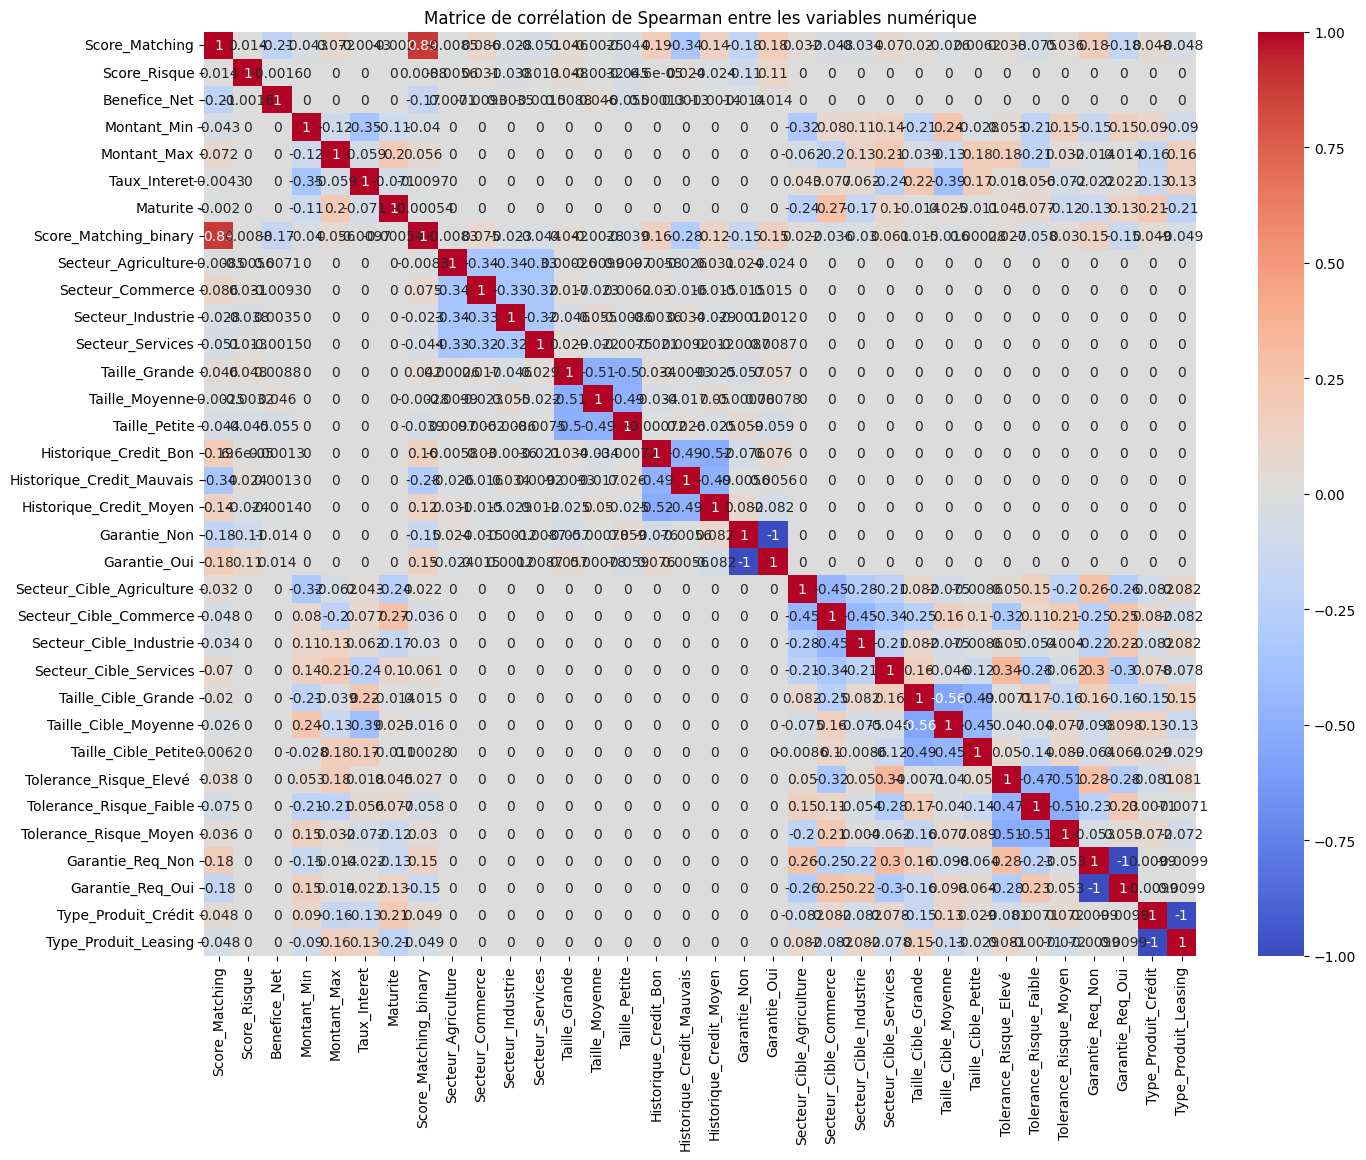

In [ ]:
# sélecion des variables numériques
num_vars=data1.select_dtypes(include=np.number).columns

#calcul de la matrice de corrélation de spearman
corr_matrix=data1[num_vars].corr(method='spearman')

#Affichage de la matrice de corrélation de Spearman
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation de Spearman entre les variables numérique")
plt.show()


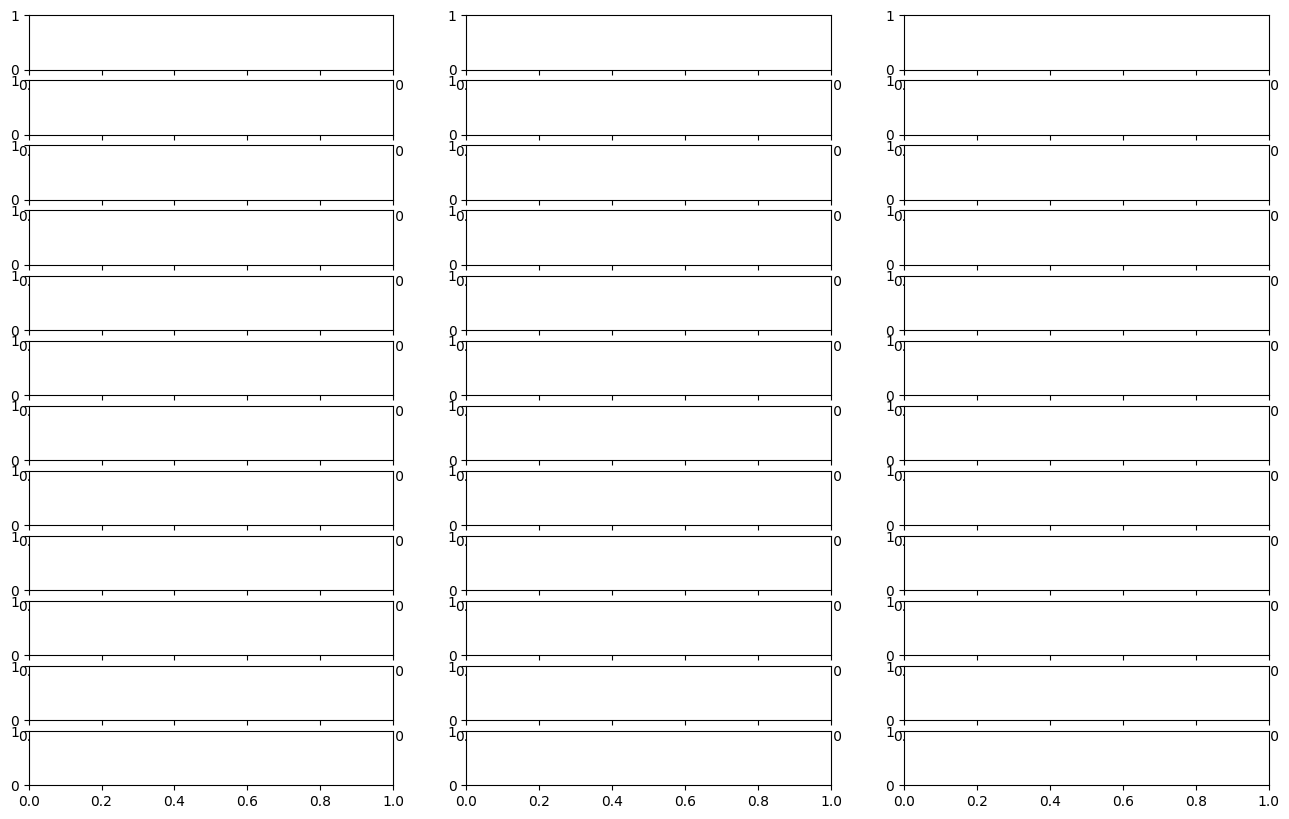

In [ ]:
#4.2 Relation entre variable cible 'median_house_value' et les variables numérique
# Sélection des variables numériques
num_vars=data1.select_dtypes(include=np.number).columns

# calcul de la taille de la matrice des subplots en fonction du nombre de variables numériques
n_cols=3
n_rows=int(np.ceil(len(num_vars)/n_cols))

# Affichage des scatterplots pour chaque variable numériquee sur une meme fugure avec des subplots
fig, axs=plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16,10))
axs=axs.flatten()

In [ ]:
#Préparation des données

In [ ]:
#Préparation des données
X = data1.drop(['Score_Matching', 'Score_Matching_binary'], axis=1)
y = data1['Score_Matching']
y_binary = data1['Score_Matching_binary']

# Division des données en ensemble d'apprentissage et de test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
X.columns

In [ ]:
y

In [ ]:
import xgboost as xgb

In [ ]:
X_train.columns=X_train.columns.str.replace('<', '') #Replace < character
X_test.columns=X_test.columns.str.replace('<', '') #Replace < character

In [ ]:
#Définition de l'objet XGBoost regressor
xgb_reg=xgb.XGBRegressor(random_state=42)

#Paramétrage à optimisés
parameters={
    #max_depth est la profondeur maximale de chaque arbre.une valeur élevée rendra le modèle plus complexe
    'max_depth':[7, 9, 11],

    # Learning_rate (ou taux d'apprentissage) est le pas d'ajustement effectué à chaque étape de l'optimisation
    'learning_rate':[1, 1.5, 2],

     # construiren_estimations est le nombre d'arbres à construire
    'n_estimators':[1200, 1500, 1800],

    #min_child_weight controle le surapprentissage.
    'min_child_weight':[1, 3, 5],

    #Gamma est une mesure de la complexité du modele permise. plus gamma est élevé plus le modèle est conservante
    'gamma':[0, 0.1, 0.2]
}


In [ ]:
#XGBoost avec optimisation des parametre

In [ ]:
from sklearn.model_selection import GridSearchCV
import time
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [ ]:
# Création du modèle XGBoost avec early stopping et enregistrement des métriques d'évaluation
xgb_reg1 = xgb.XGBRegressor(objective='reg:squarederror')
# Création de l'objet GridSearch avec validation croisée
grid_search = GridSearchCV(
    xgb_reg,
    parameters,
    cv=5,
    n_jobs=-1,
    verbose=1,
    error_score='raise',
    scoring='neg_mean_squared_error',  # Vous pouvez ajuster cela à la métrique désirée
    return_train_score=True
)

# Enregistrement du temps actuel
start_time = time.time()

# Entraînement du modèle avec GridSearch en suivant l'évolution
eval_set = [(X_train, y_train), (X_valid, y_valid)]  # Ajoutez vos données de validation ici
grid_search.fit(
    X_train, y_train,
    eval_metric='rmse',  # Choisissez la métrique souhaitée
    eval_set=eval_set,
    early_stopping_rounds=10,
    verbose=True  # Affiche les résultats à chaque itération
)

# Calcul du temps d'exécution
elapsed_time = time.time() - start_time
print(f"Temps de calcul : {elapsed_time} secondes")

# Affichage des meilleurs paramètres
print("Best parameters set :")
print(grid_search.best_params_)

# Affichage des résultats des métriques
results = grid_search.cv_results_
for mean_score, params in zip(results['mean_test_score'], results['params']):
    print(f"Mean Test Score: {mean_score:.4f} with parameters: {params}")

# Optionnel: Afficher les résultats des métriques d'entraînement et de validation
best_model = grid_search.best_estimator_
evals_result = best_model.evals_result()
print("Évolution des métriques d'entraînement et de validation :")
print(evals_result)

In [ ]:
# Création de l'objet Gridsearch
grid_search=GridSearchCV(xgb_reg, parameters, cv=5, n_jobs=-1, verbose=1, error_score='raise')

# Enregistrement du temps actuel
start_time=time.time()

#Entraînement du modéle avec GridSearch
grid_search.fit(X_train, y_train)

# Calcul du temps d'exécution
elapsed_time=time.time()-start_time
print(f"Temps de calcul : {elapsed_time} secondes")

#Affichage des meilleurs parametres
print(" Best parameters set : ")
print(grid_search.best_params_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Temps de calcul : 9049.010252475739 secondes
 Best parameters set : 
{'gamma': 0, 'learning_rate': 1, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 1500}


In [ ]:
def model_performance(model, X_train, X_test, y_train, y_test ):
    #Prédictions sur l'ensemble d'entraînement et de test
    #Prédiction sur l'ensemble de test
    y_test_pred=model.predict(X_test)
    y_train_pred=model.predict(X_train)

    #Calcul des mesures de performance
    r2_train=r2_score(y_train, y_train_pred)
    r2_test=r2_score(y_test, y_test_pred)

    rmse_train=np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test=np.sqrt(mean_squared_error(y_test, y_test_pred))

    mae_train=mean_absolute_error(y_train, y_train_pred)
    mae_test=mean_absolute_error(y_test, y_test_pred)

    #Création du dataframe
    performance=pd.DataFrame({
        'Score':['R2','RMSE','ME'],
        'Train':[r2_train, rmse_train,mae_train],
        'Test':[r2_test,rmse_test,mae_test]
    })
    return performance

In [ ]:
performance=model_performance(grid_search.best_estimator_, X_train, X_test, y_train, y_test)
performance

,Score,Train,Test
0,R2,0.999994,0.933744
1,RMSE,0.042471,4.271229
2,ME,0.029638,3.113721


                      Feature  Importance
31       Type_Produit_Leasing    0.000000
29           Garantie_Req_Oui    0.000000
17               Garantie_Oui    0.000000
15    Historique_Credit_Moyen    0.000743
13      Historique_Credit_Bon    0.001022
20    Secteur_Cible_Industrie    0.004208
5                    Maturite    0.005321
2                 Montant_Min    0.007211
1                Benefice_Net    0.007461
9            Secteur_Services    0.007481
24        Taille_Cible_Petite    0.009466
6         Secteur_Agriculture    0.010668
0                Score_Risque    0.012414
3                 Montant_Max    0.013124
12              Taille_Petite    0.013272
7            Secteur_Commerce    0.014963
10              Taille_Grande    0.015739
11             Taille_Moyenne    0.019637
18  Secteur_Cible_Agriculture    0.020094
23       Taille_Cible_Moyenne    0.021339
27     Tolerance_Risque_Moyen    0.022258
4                Taux_Interet    0.029279
8           Secteur_Industrie    0

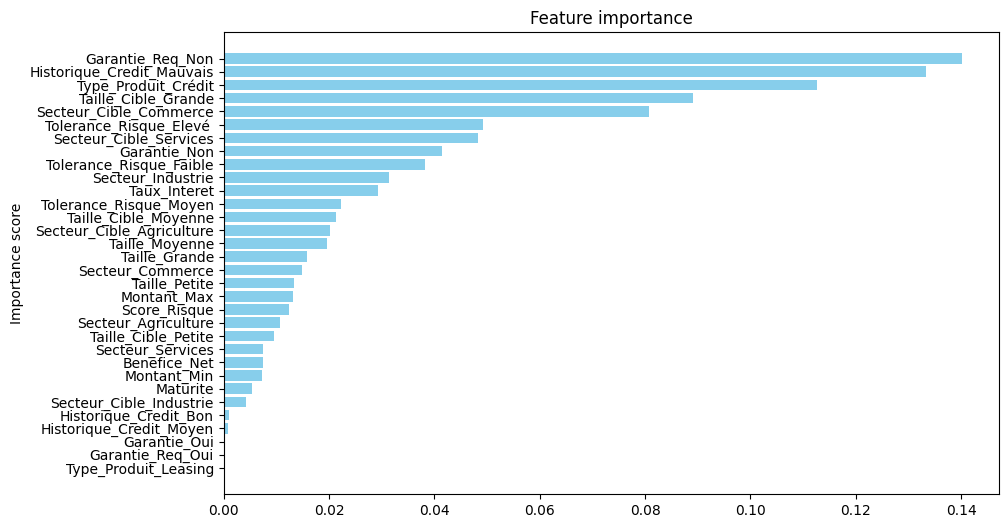

In [ ]:
#Obtention des importances des caractéristiques
#importance des variables
feature_importances =grid_search.best_estimator_.feature_importances_

#Création du dataFrame d'importance des variables
importance_df=pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
    }).sort_values(by='Importance', ascending=True)

#affichage de DataFrame d'imprtance des variables
print(importance_df)

#Affichage du graphique d'importance des variables
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.title('Feature importance')
plt.ylabel('Importance score')
plt.show()

In [ ]:
import joblib

# Enregistrer le modèle XGBoost optimisé
model_filename = '/content/drive/MyDrive/kiotaData/dataset/matching_v01.model'
joblib.dump(grid_search.best_estimator_, model_filename)
print(f"Modèle enregistré sous le nom : {model_filename}")

Modèle enregistré sous le nom : /content/drive/MyDrive/kiotaData/dataset/matching_v01.model
